<center>
  <h1>
  <h2>Bioinformática y Fidelidad Cuántica</h2>
  <br>
  <h3>Curso de Computación Cuántica, 2026-1</h3>
  <h3>Facultad de Ingeniería</h3>
  <h3>Universidad de Antioquia</h3>
  <h6>Sebastián Castaño Quinchía</h6>
  <br>
</center>

### Objetivos

* Comparar secuencias de ADN usando fidelidad cuántica como métrica de similitud.

* Implementar circuitos cuánticos $\widehat U$ y $\widehat U^\dagger$ que permiten codificar secuencias de ADN como un estado cuántico superpuesto de $n$ qubits.

* Evaluar dicha fidelidad mediante observables cuanticos definidos en Qiskit.

### Marco teórico

1. **Introducción a la comparación genética:**

Una de las mayores aplicaciones en la bioinformática es la comparación de cadenas de strings provenientes de secuencias genéticas de DNA y RNA. Tradicionalmente, se utilizan técnicas como:

* Alineamiento de secuencias (Needleman-Wunsch, BLAST).

* Distancias de Hamming o Levenshtein.

Estas técnicas buscan medir qué tan similares son dos cadenas de ADN.

En  esta  práctica  de  laboratorio  utilizaremos  las  bondades  de  la  superposición,  la reversibilidad cuántica y el cálculo de la fidelidad cuántica, para comparar múltiples secuencias  de  caracteres  provenientes  de  la  secuenciación  genética  de  diferentes microorganismos y especies biológicas.

2. **Enfoque cuántico:**

En computación cuántica, podemos representar una secuencia genética como un estado cuántico, de manera que:

* **La Secuencia 1**: Se representa mediante un estado $|\psi⟩$.

* **La Secuencia 2**: Se representa mediante un estado $|\phi \rangle$.

La similitud entre ambas secuencias se mide entonces mediante la fidelidad cuántica:

$$F = |\langle \phi | \psi \rangle|^2$$

* Si las secuencias son idénticas, entonces $F=1$.
* Si son diferentes, entonces $0<F<1$.
* Y si son ortogonales, $F=0$.

3. **Codificación cuántica de las secuencias ADN:**

Dado que en `Qiskit` los qubits se inicializan por defecto con el estado $|0\rangle$, cada secuencia genética se debe codificar como un estado cuántico de $n$ qubits entrelazados que se obtiene a partir de la aplicación de una compuerta cuántica unitaria y reversible $\widehat U$ sobre el estado $|0\rangle^{\otimes n}$:

$$|\boldsymbol{\psi}\rangle = \widehat U_\psi |0\rangle^{\otimes n} \quad \text{y} \quad |\boldsymbol{\phi}\rangle = \widehat U_\phi |0\rangle^{\otimes n}$$

Donde $\widehat U_\psi, \widehat U_\phi$ son los circuitos cuánticos (compuertas unitarias) que se deben implementar.

4. **Implementación de los circuitos cuánticos de codificación:**

En un computador clásico, para codificar una secuencia genética de $N$ dígitos (cadena de bases de ADN compuestas por los nucleótidos T, G, C y A) se utilizan dos bits por base, tal que $T \rightarrow 00$, $G \rightarrow  01$, $C \rightarrow  10$, $A \rightarrow  11$, y por ejemplo, una secuencia ATCG se traduzca en el computador como el byte 00110110.

Dentro de un circuito cuántico en `Qiskit`, en lugar de cargar cada base de forma secuencial, la función genera una superposición uniforme de la forma:

$$\vert{} \psi_{\text{initialized}} \rangle = \frac{1}{\sqrt{N}} \sum_{i=0}^{N-1} \vert{} \text{posicion}_i, \text{base}_i \rangle$$

Donde $i = 0,1, ..., N-1$, es la posición de los caracteres en la cadena y $N = 2^{n-2}$. Esto significa que toda la cadena de ADN existe simultáneamente en un solo estado cuántico de $n$ qubits:

$$n = \lceil \log_2(N) \rceil + 2$$

Donde $\lceil \log_2(L) \rceil$ representa la cantidad mínima de qubits requeridos para direccionar la posición de cada base en la cadena, y se añaden $2$ qubits adicionales para codificar los $4$ posibles estados de las bases nitrogenadas ($2^2 = 4$). Así, el espacio de estados cuánticos resultante tiene una dimensión de $2^n$.

Para cada nucleótido situado en la posición $i$ de la secuencia se calcula su posición base desplazada por un factor de 4 ($\text{pos} = i \times 4$) y se le suma un valor correspondiente a su tipo de base:

* T $\rightarrow \text{pos} + 0 \Longrightarrow | \text{pos} \rangle \otimes |00 \rangle$

* G $\rightarrow \text{pos} + 1 \Longrightarrow | \text{pos} \rangle \otimes |01 \rangle$

* C $\rightarrow \text{pos} + 2 \Longrightarrow | \text{pos} \rangle \otimes |10 \rangle$

* A $\rightarrow \text{pos} + 3 \Longrightarrow | \text{pos} \rangle \otimes |11 \rangle$

La idea de sumar en la posición es para recorrer un vector de amplitudes para ubicar la posición de los caracteres y asignar las amplitudes. De esta manera, el vector de estado deseado $\vert{}\psi_{\text{initialized}}\rangle$ se construye como una superposición uniforme y todos los demás estados que no corresponden a la secuencia codificada mantienen una amplitud igual a cero.

Con el vector de estado normalizado $\vert{}\psi_{\text{initialized}}\rangle$, se utiliza la instrucción `Initialize(desired_vector)` de `Qiskit`, la cual sintetiza la transformación unitaria $\widehat{U}$ capaz de transformar el estado base computacional $\vert{}0\rangle^{\otimes n}$ en la superposición objetivo que representa la secuencia de ADN:

$$\vert{}\psi\rangle = \widehat{U}_\psi \vert{}0\rangle^{\otimes n}$$

**Por ejemplo**, para la codificación de una cadena "TC", $N=2$ y el número de qubits requeridos es $n = \lceil \log_2(2) \rceil + 2 = 1 + 2 = 3$, de modo que el espacio de Hilbert tiene dimensión $2^3 = 8$ estados computacionales (desde $\vert{}000\rangle$ hasta $\vert{}111\rangle$).

Calculamos la amplitud de probabilidad como:

$$A = \sqrt{\frac{1}{2^{3-2}}} = \sqrt{\frac{1}{2^1}} = \frac{1}{\sqrt{2}} \approx 0.7071$$

Inicializamos un vector de amplitudes con 8 posiciones en cero:

$$\vec{v_A} = [0, 0, 0, 0, 0, 0, 0, 0]$$

Mapeamos cada nucleótido según su posición $i$:

* Primer nucleótido ($i = 0$, base T): $\text{pos} = 0 \times 4 = 0$. Como $b = \text{"T"}$, sumamos $0$ a la posición, obteniendo $\mathbf{\text{pos}} = 0$ y asignamos la amplitud: $\text{desired\_vector}[0] = \frac{1}{\sqrt{2}}$.

* Segundo nucleótido ($i = 1$, base C):$\text{pos} = 1 \times 4 = 4$. Como $b = \text{"C"}$, le sumamos $2$ a la posición, $\mathbf{\text{pos}} = 6$ y asignamos la amplitud: $\text{desired\_vector}[6] = \frac{1}{\sqrt{2}}$

De esta manera, el vector de amplitudes resultante en el espacio de Hilbert es:

$$\vec{v_A} = \left[ \frac{1}{\sqrt{2}}, \, 0, \, 0, \, 0, \, 0, \, 0, \, \frac{1}{\sqrt{2}}, \, 0 \right]$$

Convertimos los índices decimales a binario de 3 qubits ($0 = \vert{}000\rangle$ y $6 = \vert{}110\rangle$), así, el estado resultante es:

$$\vert{}\psi_{\text{TC}}\rangle = \widehat{U}_{\text{TC}} \vert{}000\rangle = \frac{\vert{}000\rangle + \vert{}110\rangle}{\sqrt{2}}$$

Al medir este circuito, obtendrás un 50% de probabilidad de colapsar al estado $\vert{}000\rangle$ (que representa a T en la posición 0) y un 50% de probabilidad de colapsar a $\vert{}110\rangle$ (que representa a C en la posición 1).

4. **Comparación de secuencias mediante compuertas inversas:**

Para comparar ambos estados, se construye entonces el circuito $\widehat U_\phi^\dagger \widehat U_\psi$, el cual se aplica sobre el estado base $\vert{}\mathbf{0}\rangle^{\otimes n}$:

$$\widehat U_\phi^\dagger \widehat U_\psi \vert{}0\rangle^{\otimes n}$$

En este circuito cuántico, si $\widehat U_\psi = \widehat U_\phi$, entonces $\widehat U_\phi^\dagger \widehat U_\psi = I$ (operador identidad).

Como los estados asociados a T, G, C y A ocupan subespacios mutuamente ortogonales en la base computacional (por ejemplo, $\vert{}00\rangle$, $\vert{}01\rangle$, $\vert{}10\rangle$, $\vert{}11\rangle$ en los qubits de nucleótido):

$$\langle \text{Base}_A \vert{} \text{Base}_B \rangle = 0 \quad \text{si } A \neq B$$

Si dos cadenas difieren en la posición $i$, los vectores de estado en ese bloque serán estrictamente ortogonales, reduciendo directamente la fidelidad total $\langle \phi \vert{} \psi \rangle$.

Por lo tanto, como se observa en la siguiente demostración, la comparación final de las secuencias genéticas se reduce a: ¿Qué tan cerca está el resultado del estado $\vert{}0\dots0\rangle$?

> $$F(|\psi \rangle, |\phi \rangle) = \langle\phi| \psi\rangle\langle\psi| \phi\rangle = \langle\phi| \hat{\Pi}_\psi |\phi\rangle = \langle 0| \hat{U}_\phi^\dagger \hat{U}_\psi |0 \rangle \langle 0| \hat{U}_\psi^\dagger \hat{U}_\phi |0\rangle $$
>
> Definimos el estado $|\alpha \rangle = \hat{U}_\phi^\dagger \hat{U}_\psi |0 \rangle^{\otimes n}$, por lo tanto:
>
> $$F(|\psi \rangle, |\phi \rangle) = \langle 0| \alpha \rangle\langle\alpha| 0\rangle = |\langle \alpha |0\rangle^{\otimes n} |^2 = F(| \alpha \rangle, |0 \rangle^{\otimes n})$$
>
> Esta fidelidad es la probabilidad de que acontezca $|0\rangle^{\otimes n}$ en un proceso de simulación de $|\alpha \rangle$.

### Algoritmos de codificación de las secuencias de ADN

In [ ]:
!pip install qiskit                 &> /dev/null
!pip install qiskit-ibm-runtime     &> /dev/null
!pip install qiskit[visualization]  &> /dev/null
!pip install qiskit-aer             &> /dev/null

In [ ]:
import sys
import numpy as np
import math

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

# , execute, BasicAer, IBMQ
from qiskit.visualization import plot_histogram, plot_bloch_multivector

# from qiskit.extensions import Initialize
from qiskit.circuit.library import Initialize

from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Statevector

from qiskit_aer import AerSimulator

In [ ]:
def DNA2QuantumCircuit(bitstring, qr, cr):
    """
    Este circuito se encarga de codificar las secuencias de ADN a estados cuánticos,
    utilizando la técnica de codificación Amplitud Encoding, la cual crea un circuito para construir la superposición cuántica de la cadena de bits
    """
    n = math.ceil(math.log2(len(bitstring))) +2                 # Número de qubits
    assert n>2, "La longitud de la cadena de bits debe ser de al menos 2."

    qc = QuantumCircuit(qr, cr)

    # Inicialización del vector de amplitud de probabilidad del estado deseado
    desired_vector = np.array([ 0.0 for i in range(2**n) ])     # Inicializar a cero

    # print(len(desired_vector))

    # display(array_to_latex(Statevector(desired_vector), prefix="\\ket{\\psi_0} = "))

    qc_init = QuantumCircuit(n)       # Creación de compuertas circuitales para inicialización

    # Amplitud de superposición uniforme de la base computacional de n qubits
    amplitude = np.sqrt(1.0/2**(n-2))

    for i, b in enumerate(bitstring):
        pos = i*4
        if b == "T":
            pos += 0
        elif b == "G":
            pos += 1
        elif b == "C":
            pos += 2
        elif b == "A":
            pos += 3
        desired_vector[pos] = amplitude

    # display('El vector de estado del circuito es', array_to_latex(Statevector(desired_vector), prefix="\\ket{\\psi_{initilized}} = "))

    # Preparación del estado cuántico a partir de las amplitudes
    init = Initialize(desired_vector)

    qc_init.append(init, qc_init.qubits)
    qc.append(qc_init, qr)
    qc.barrier(qr)

    return qc
# ------------------------------------------------------------------------------

def DNA2InvQuantumCircuit(bitstring, qr, cr):
    """
    crear un circuito para construir la superposición cuántica de la cadena de bits
    """
    n = math.ceil(math.log2(len(bitstring))) + 2                 # Número de qubits
    assert n > 2, "the length of bitstring must be at least 2"

    qc = QuantumCircuit(qr, cr)

    # Amplitud de probabilidad del estado deseado
    desired_vector = np.array([ 0.0 for i in range(2**n) ])

    # print(len(desired_vector))

    # display(array_to_latex(Statevector(desired_vector), prefix="\\ket{\\psi_0} = "))

    inverse_qc_init = QuantumCircuit(n) # Creación de compuertas circuitales para inversión de la inicialización

    amplitude = np.sqrt(1.0/2**(n-2))

    for i, b in enumerate(bitstring):
        pos = i * 4
        if b == "T":
            pos += 0
        elif b == "G":
            pos += 1
        elif b == "C":
            pos += 2
        elif b == "A":
            pos += 3
        desired_vector[pos] = amplitude

    # display('El vector de estado del circuito es', array_to_latex(Statevector(desired_vector), prefix="\\ket{\\psi_{initilized}} = "))

    init = Initialize(desired_vector)

    uncompute = init.gates_to_uncompute().decompose()

    inverse_qc_init.append(uncompute, inverse_qc_init.qubits)
    qc.append(inverse_qc_init, qr)

    qc.barrier(qr)
    for i in range(n):
        qc.measure(qr[i], cr[i])
    print()
    return qc

### Comparación de cadenas de ADN

2.1. Implemente en Qiskit el circuito cuántico mostrado para generar las secuencias de ADN.

Cada secuencia genética se codifica entonces como un circuito cuántico:

$$|\psi\rangle = \hat U_{\psi}|0\rangle^{\otimes n} \quad \text{y} \quad |\phi\rangle = \hat U_{\phi}|0\rangle^{\otimes n}$$

Donde: $\hat U_{\psi}, \hat U_{\phi}$: Son circuitos cuánticos que se pueden generar mediante la biblioteca **ConvertDNA2Quantum.py**


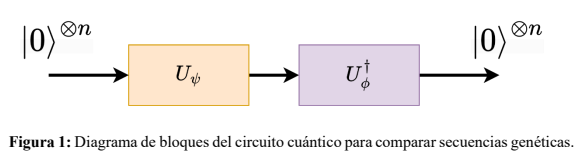

In [ ]:
def fidelidad(ADN1, ADN2):
  #
  # ------------ Implementación del circuito para el estado |alpha> ------------
  n = math.ceil(math.log2(len(ADN1))) + 2
  qr = QuantumRegister(n, "q")
  cr = ClassicalRegister(n, "c")

  Uphi = DNA2QuantumCircuit(ADN1, qr, cr)
  Upsi = DNA2InvQuantumCircuit(ADN2, qr, cr)

  cir = Uphi.compose(Upsi)
  # cir1.draw("mpl")

  # ------------ Cálculo de la fidelidad a través de simulación ------------
  shots = 4000
  sim = AerSimulator()
  compiled = transpile(cir, sim)
  result = sim.run(compiled, shots=shots).result()
  counts = result.get_counts()

  # Contamos los estados iguales a |0>^{⊗n} que acontecieron
  F_0alpha = counts.get("0"*n, 0)/shots

  print(f'La fidelidad entre las secuencias de ADN:')
  print(f'-> ADN1: {ADN1}')
  print(f'-> ADN2: {ADN2}')
  print(f'\tF(ADN1, ADN2) es: {F_0alpha}')
# ----------------------------

ADN1 = "CCGTTAAGGCTAGCTA"     # Grupo 8
ADN2 = "CGATGGTACCTTGATA"     # Grupo 3

fidelidad(ADN1, ADN2)


La fidelidad entre las secuencias de ADN:
-> ADN1: CCGTTAAGGCTAGCTA
-> ADN2: CGATGGTACCTTGATA
F(ADN1, ADN2) es: 0.19775


Como una prueba del buen funcionamiento del programa en Qiskit, veamos el resultado de similaridad de una de las secuencias genéticas consigo misma.

> En teoría, si $|\phi \rangle = |\psi \rangle$, $\hat{U}_\phi^\dagger = \hat{U}_\psi^\dagger$, lo que implica que $|\alpha \rangle = \hat{U}_\psi^\dagger \hat{U}_\psi |0 \rangle = \hat 1 |0 \rangle = |0 \rangle^{\otimes n}$. Así:
>
> $$F(|\psi \rangle, |\psi \rangle) = \langle 0| \alpha \rangle\langle\alpha| 0\rangle = |\langle 0 |0\rangle^{\otimes n} |^2 = F(| 0 \rangle^{\otimes n}, |0 \rangle^{\otimes n}) = 1$$

In [ ]:
fidelidad(ADN1, ADN1)


La fidelidad entre las secuencias de ADN:
-> ADN1: CCGTTAAGGCTAGCTA
-> ADN2: CCGTTAAGGCTAGCTA
F(ADN1, ADN2) = 1.0


Veamos la explicación de los componentes de cada circuito cuántico implementado.

> $\hat{U}_\psi$: Corresponde al operador de inicialización, y se encarga de transformar el estado base $|0 \rangle^{\otimes n}$ en un estado de superposición uniforme que representa la primera secuencia de ADN: $|\psi\rangle = \hat U_{\psi}|0\rangle^{\otimes n}$.
>
> Internamente, de la secuencia de $N$ caracteres, codifica en $n_1 = \log_2 N$ qubits la posición de los caracteres en la cadena, y en $n_2 = 2$ qubits las posibles bases genéticas $T:00, G:01, C:10, A:11$. Todos los caracteres se codifican en un estado de $n = n_1 + n_2$ qubits, que corresponde a una superposición uniforme de los estados provenientes de los caracteres codificados.

> $\hat{U}_\phi^\dagger$: Corresponde al operador transpuesto conjugado del operador de inicialización $\hat{U}_\phi$, con la misma estructura del anterior, pero aplicado a la segunda secuencia de ADN, que es representada por un estado de superposición uniforme de la forma $|\phi\rangle = \hat U_{\phi}|0\rangle^{\otimes n}$.
>
> Si ambas secuencias son iguales, este operador deshace la superposición y devuelve el sistema al estado $|0 \rangle^{\otimes n}$.

Resultados de las 3 comparaciones escogidas, determinando el grado de similaridad genética entre las diferentes secuencias.

In [ ]:
ADN1 = "CCGTTAAGGCTAGCTA"     # Grupo 8
ADN2 = "CGATGGTACCTTGATA"     # Grupo 3
ADN3 = "CCGTTAAGGCCTGATA"     # Secuencia alternativa con más caracteres similares

fidelidad(ADN1, ADN2)
fidelidad(ADN1, ADN3)
fidelidad(ADN1, ADN1)


La fidelidad entre las secuencias de ADN:
-> ADN1: CCGTTAAGGCTAGCTA
-> ADN2: CGATGGTACCTTGATA
F(ADN1, ADN2) es: 0.18425

La fidelidad entre las secuencias de ADN:
-> ADN1: CCGTTAAGGCTAGCTA
-> ADN2: CCGTTAAGGCCTGATA
F(ADN1, ADN2) es: 0.666

La fidelidad entre las secuencias de ADN:
-> ADN1: CCGTTAAGGCTAGCTA
-> ADN2: CCGTTAAGGCTAGCTA
F(ADN1, ADN2) es: 1.0


Observamos que cuando las secuencias tienen los mismos caracteres en sus correspondientes posiciones, esto es, se parecen más, el grado de fidelidad crece.